# 0 - Basic Validation

This notebook validates core data quality assumptions before modeling, with emphasis on:
- numeric outliers (boxplots + IQR summary),
- target distributions (`Opportunity Amount USD` and `Opportunity Result`),
- process consistency checks (`Total Days...` + stage ratios),
- repeated records per `Opportunity Number`.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')


In [2]:
DATA_PATH = '../../data/raw/cars.xlsx'
df = pd.read_excel(DATA_PATH)

print('shape:', df.shape)
print('columns:', len(df.columns))
display(df.head(3))


shape: (78025, 19)
columns: 19


,Opportunity Number,Supplies Group,Supplies Subgroup,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue (USD),Client Size By Employee Count,Revenue From Client Past Two Years (USD),Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category (USD)
0,1641984,Car Accessories,Exterior Accessories,Northwest,Fields Sales,76,Won,13,104,101,0,More than 1M,More than 25K,0 (No business),Unknown,0.6964,0.1140,0.1542,10K or less
1,1658010,Car Accessories,Exterior Accessories,Pacific,Reseller,63,Loss,2,163,163,0,250K to 500K,More than 25K,0 (No business),Unknown,0.0000,1.0000,0.0000,10K or less
2,1674737,Performance & Non-auto,Motorcycle Parts,Pacific,Reseller,24,Won,7,82,82,7750,100K or less,1K or less,0 (No business),Unknown,1.0000,0.0000,0.0000,10K or less


## 1) Target distributions


In [3]:
target_col_amount = 'Opportunity Amount USD'
target_col_result = 'Opportunity Result'

result_dist = (
    df[target_col_result]
    .value_counts(dropna=False)
    .rename('count')
    .to_frame()
)
result_dist['pct'] = (result_dist['count'] / len(df) * 100).round(2)

amount_summary = df[target_col_amount].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('value')

print('Opportunity Result distribution:')
display(result_dist)
print('Opportunity Amount USD summary:')
display(amount_summary)


Opportunity Result distribution:


,count,pct
Opportunity Result,,
Loss,60398,77.4100
Won,17627,22.5900


Opportunity Amount USD summary:


,value
count,"78,025.0000"
mean,"91,637.2607"
std,"133,161.0292"
min,0.0000
1%,0.0000
5%,"1,192.8000"
25%,"15,000.0000"
50%,"49,000.0000"
75%,"105,099.0000"
95%,"350,000.0000"


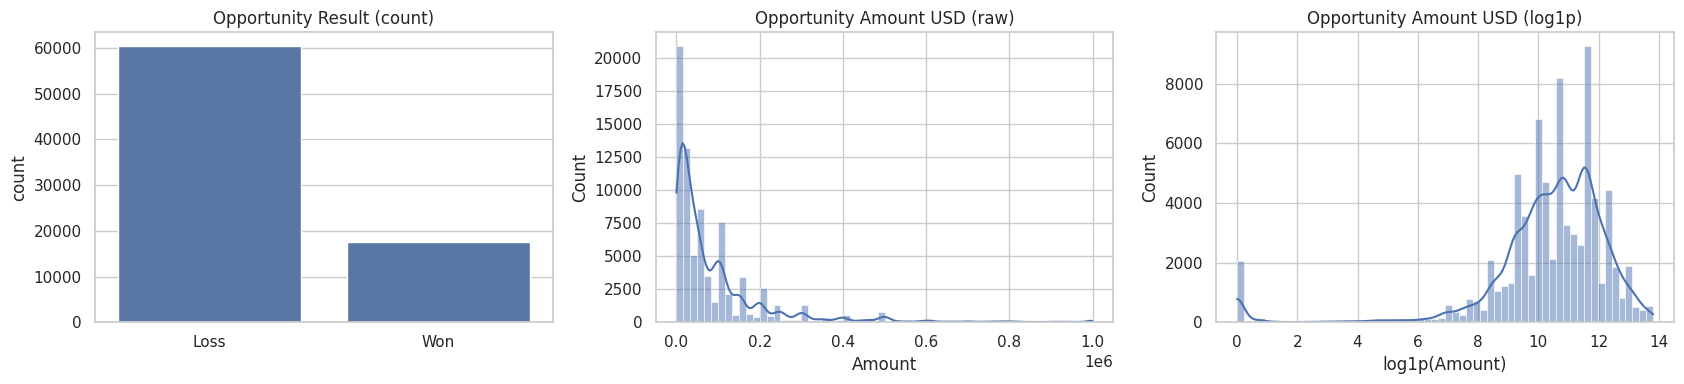

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

order = df[target_col_result].value_counts().index
sns.countplot(data=df, x=target_col_result, order=order, ax=axes[0])
axes[0].set_title('Opportunity Result (count)')
axes[0].set_xlabel('')

sns.histplot(df[target_col_amount], bins=60, kde=True, ax=axes[1])
axes[1].set_title('Opportunity Amount USD (raw)')
axes[1].set_xlabel('Amount')

sns.histplot(np.log1p(df[target_col_amount]), bins=60, kde=True, ax=axes[2])
axes[2].set_title('Opportunity Amount USD (log1p)')
axes[2].set_xlabel('log1p(Amount)')

plt.tight_layout()


## 2) Numeric outliers (IQR + boxplots)


In [5]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_count = ((df[numeric_cols] < lower) | (df[numeric_cols] > upper)).sum().rename('outlier_count')
outlier_pct = (outlier_count / len(df) * 100).rename('outlier_pct')

outlier_table = pd.concat([
    q1.rename('q1'),
    q3.rename('q3'),
    iqr.rename('iqr'),
    lower.rename('lower_bound'),
    upper.rename('upper_bound'),
    outlier_count,
    outlier_pct.round(2)
], axis=1).sort_values('outlier_pct', ascending=False)

outlier_table


,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
Ratio Days Identified To Total Days,0.0000,0.1972,0.1972,-0.2958,0.4931,14983,19.2000
Ratio Days Qualified To Total Days,0.0000,0.1886,0.1886,-0.2828,0.4714,14948,19.1600
Sales Stage Change Count,2.0000,3.0000,1.0000,0.5000,4.5000,9340,11.9700
Opportunity Amount USD,"15,000.0000","105,099.0000","90,099.0000","-120,148.5000","240,247.5000",7273,9.3200
Total Days Identified Through Closing,4.0000,24.0000,20.0000,-26.0000,54.0000,2706,3.4700
Total Days Identified Through Qualified,4.0000,24.0000,20.0000,-26.0000,54.0000,2566,3.2900
Opportunity Number,"6,900,423.0000","8,228,329.0000","1,327,906.0000","4,908,564.0000","10,220,188.0000",143,0.1800
Elapsed Days In Sales Stage,19.0000,65.0000,46.0000,-50.0000,134.0000,6,0.0100
Ratio Days Validated To Total Days,0.0000,1.0000,1.0000,-1.5000,2.5000,0,0.0000


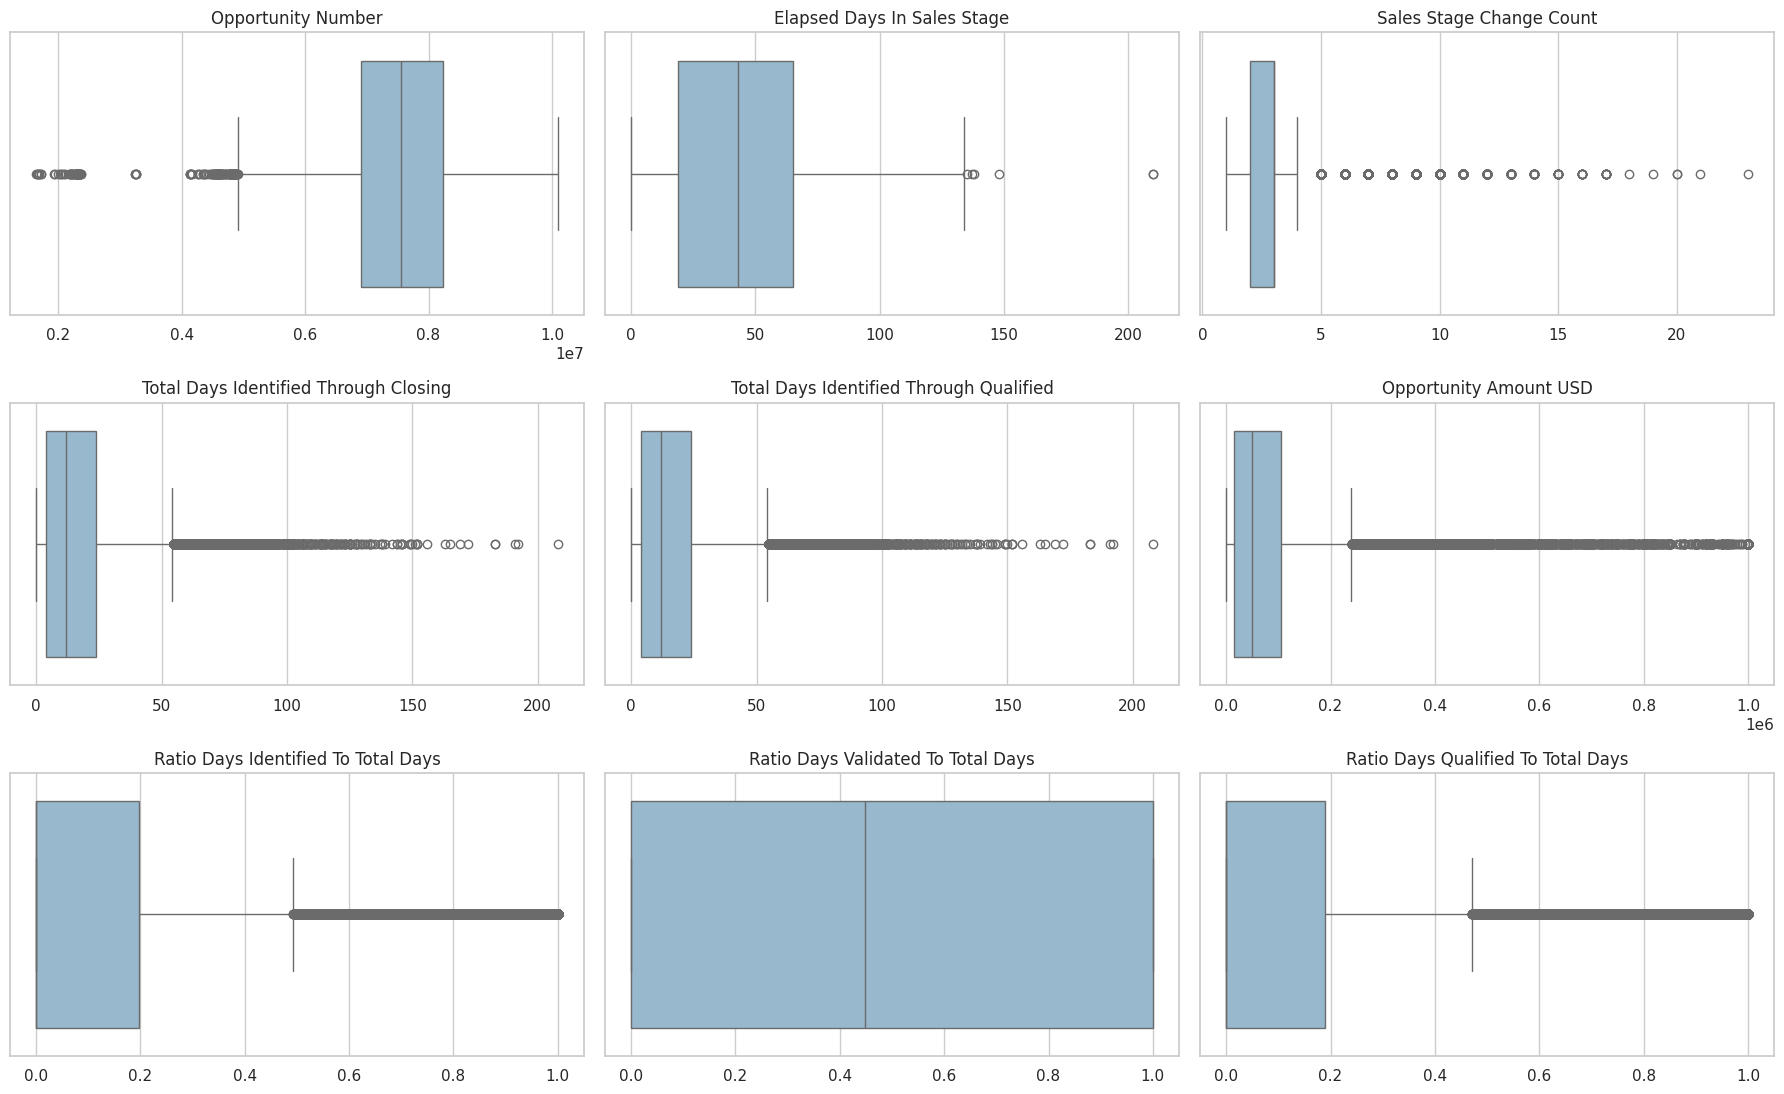

In [6]:
n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.7 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='#8fbad6')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()


## 3) Process consistency checks


In [7]:
total_days_col = 'Total Days Identified Through Closing'
total_siebel_col = 'Total Days Identified Through Qualified'
ratio_cols = [
    'Ratio Days Identified To Total Days',
    'Ratio Days Validated To Total Days',
    'Ratio Days Qualified To Total Days'
]

check = df[[total_days_col, total_siebel_col] + ratio_cols].copy()
check['ratio_sum'] = check[ratio_cols].sum(axis=1)
check['implied_days_from_ratios'] = check['ratio_sum'] * check[total_days_col]
check['ratio_sum_abs_error'] = (check['ratio_sum'] - 1.0).abs()
check['siebel_le_total_days'] = check[total_siebel_col] <= check[total_days_col]

consistency_summary = pd.DataFrame({
    'metric': [
        'rows_total',
        'rows_total_days_negative',
        'rows_total_siebel_negative',
        'rows_total_siebel_gt_total_days',
        'rows_ratio_sum_not_close_to_1 (tol=0.01)',
        'rows_any_ratio_outside_0_1',
        'rows_ratio_days_implied_diff_gt_1day'
    ],
    'count': [
        len(check),
        int((check[total_days_col] < 0).sum()),
        int((check[total_siebel_col] < 0).sum()),
        int((~check['siebel_le_total_days']).sum()),
        int((check['ratio_sum_abs_error'] > 0.01).sum()),
        int(((check[ratio_cols] < 0) | (check[ratio_cols] > 1)).any(axis=1).sum()),
        int(((check['implied_days_from_ratios'] - check[total_days_col]).abs() > 1).sum())
    ]
})

consistency_summary['pct'] = (consistency_summary['count'] / len(check) * 100).round(2)

consistency_summary


,metric,count,pct
0,rows_total,78025,100.0000
1,rows_total_days_negative,0,0.0000
2,rows_total_siebel_negative,0,0.0000
3,rows_total_siebel_gt_total_days,0,0.0000
4,rows_ratio_sum_not_close_to_1 (tol=0.01),12921,16.5600
5,rows_any_ratio_outside_0_1,0,0.0000
6,rows_ratio_days_implied_diff_gt_1day,4127,5.2900


In [8]:
worst_ratio_rows = (
    check.assign(opportunity_number=df['Opportunity Number'])
    .sort_values('ratio_sum_abs_error', ascending=False)
    .head(15)
)

print('Top 15 rows by ratio-sum error:')
display(worst_ratio_rows[['opportunity_number', total_days_col, total_siebel_col] + ratio_cols + ['ratio_sum', 'ratio_sum_abs_error']])


Top 15 rows by ratio-sum error:


,opportunity_number,Total Days Identified Through Closing,Total Days Identified Through Qualified,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,ratio_sum,ratio_sum_abs_error
32804,8104407,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
15244,7088475,1,0,0.0000,0.0000,0.0000,0.0000,1.0000
45444,10008527,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
32801,8104193,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
15247,7088521,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
50955,6676301,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
73527,8552820,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
45441,10006296,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
45440,10006151,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
32799,8104157,0,0,0.0000,0.0000,0.0000,0.0000,1.0000


### 3.1) Early-days focus (0-1 days) for top day-related issues\n

In [9]:
top_day_issues = (
    check.assign(
        opportunity_number=df['Opportunity Number'],
        opportunity_result=df['Opportunity Result']
    )
    .sort_values('ratio_sum_abs_error', ascending=False)
    .head(15)
)

print('Top 15 day-consistency issues (sorted by ratio-sum error):')
display(
    top_day_issues[[
        'opportunity_number',
        'opportunity_result',
        total_days_col,
        total_siebel_col,
        'ratio_sum',
        'ratio_sum_abs_error'
    ]]
)

early_issue_summary = pd.DataFrame({
    'metric': [
        'top15_count',
        'top15_with_total_days_0_1',
        'top15_pct_total_days_0_1',
        'full_dataset_with_total_days_0_1',
        'full_dataset_pct_total_days_0_1'
    ],
    'value': [
        len(top_day_issues),
        int((top_day_issues[total_days_col] <= 1).sum()),
        round((top_day_issues[total_days_col] <= 1).mean() * 100, 2),
        int((check[total_days_col] <= 1).sum()),
        round((check[total_days_col] <= 1).mean() * 100, 2)
    ]
})

print('0-1 day concentration summary:')
display(early_issue_summary)


Top 15 day-consistency issues (sorted by ratio-sum error):


,opportunity_number,opportunity_result,Total Days Identified Through Closing,Total Days Identified Through Qualified,ratio_sum,ratio_sum_abs_error
32804,8104407,Loss,0,0,0.0000,1.0000
15244,7088475,Won,1,0,0.0000,1.0000
45444,10008527,Loss,0,0,0.0000,1.0000
32801,8104193,Loss,0,0,0.0000,1.0000
15247,7088521,Loss,0,0,0.0000,1.0000
50955,6676301,Won,0,0,0.0000,1.0000
73527,8552820,Loss,0,0,0.0000,1.0000
45441,10006296,Won,0,0,0.0000,1.0000
45440,10006151,Loss,0,0,0.0000,1.0000
32799,8104157,Loss,0,0,0.0000,1.0000


0-1 day concentration summary:


,metric,value
0,top15_count,15.0000
1,top15_with_total_days_0_1,14.0000
2,top15_pct_total_days_0_1,93.3300
3,full_dataset_with_total_days_0_1,"11,618.0000"
4,full_dataset_pct_total_days_0_1,14.8900


Win/Loss probability by total-days bin (first bin = 0-1):


,days_bin,opportunities,win_probability
0,0-1,11618,0.4194
1,2-3,6100,0.4621
2,4-7,10487,0.3358
3,8-14,14817,0.2086
4,15-30,21951,0.1091
5,31-60,11211,0.0712
6,61-90,1518,0.0672
7,91-180,318,0.0849
8,181-365,5,0.2000
9,366+,0,NaN


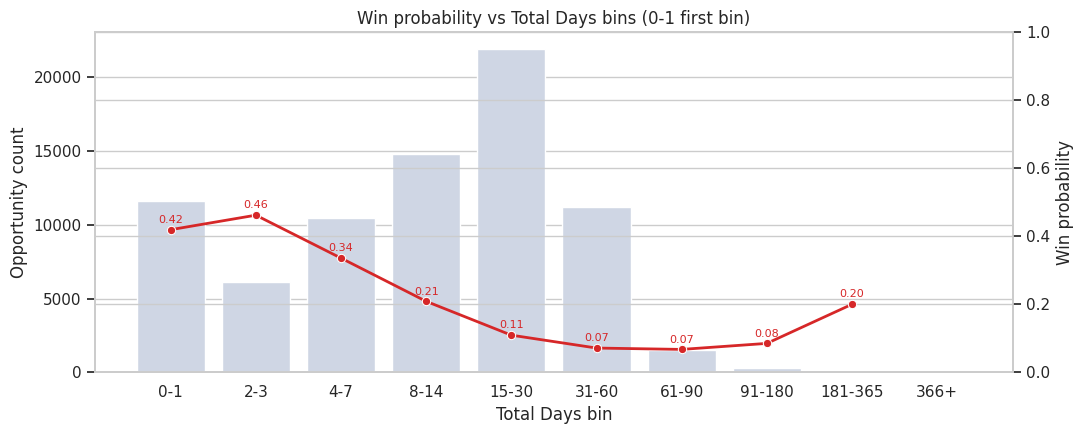

In [10]:
bin_edges = [-0.1, 1, 3, 7, 14, 30, 60, 90, 180, 365, np.inf]
bin_labels = ['0-1', '2-3', '4-7', '8-14', '15-30', '31-60', '61-90', '91-180', '181-365', '366+']

tmp = df[[total_days_col, 'Opportunity Result']].copy()
tmp['days_bin'] = pd.cut(tmp[total_days_col], bins=bin_edges, labels=bin_labels, include_lowest=True)
tmp['is_win'] = tmp['Opportunity Result'].eq('Won').astype(int)

winloss_by_bin = (
    tmp.groupby('days_bin', observed=False)
    .agg(
        opportunities=('is_win', 'size'),
        win_probability=('is_win', 'mean')
    )
    .reset_index()
)
winloss_by_bin['win_probability'] = winloss_by_bin['win_probability'].round(4)

print('Win/Loss probability by total-days bin (first bin = 0-1):')
display(winloss_by_bin)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=winloss_by_bin, x='days_bin', y='opportunities', color='#cbd5e8', ax=ax1)
ax1.set_ylabel('Opportunity count')
ax1.set_xlabel('Total Days bin')
ax1.set_title('Win probability vs Total Days bins (0-1 first bin)')

ax2 = ax1.twinx()
sns.lineplot(data=winloss_by_bin, x='days_bin', y='win_probability', marker='o', color='#d62728', linewidth=2, ax=ax2)
ax2.set_ylabel('Win probability')
ax2.set_ylim(0, 1)

for i, r in winloss_by_bin.iterrows():
    ax2.text(i, r['win_probability'] + 0.02, f"{r['win_probability']:.2f}", ha='center', fontsize=8, color='#d62728')

plt.tight_layout()


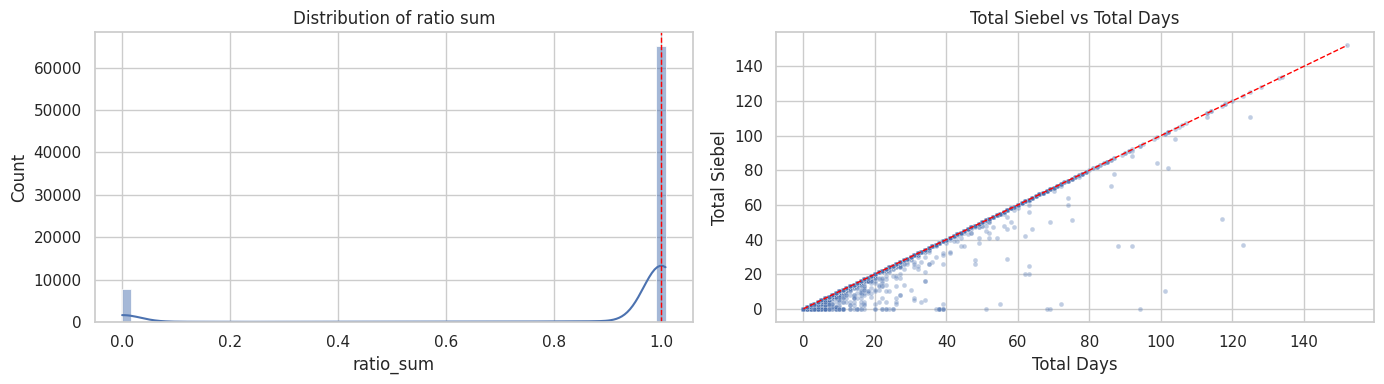

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(check['ratio_sum'], bins=60, kde=True, ax=axes[0])
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Distribution of ratio sum')
axes[0].set_xlabel('ratio_sum')

sample = check[[total_days_col, total_siebel_col]].sample(min(10000, len(check)), random_state=42)
max_lim = float(max(sample[total_days_col].max(), sample[total_siebel_col].max()))

sns.scatterplot(data=sample, x=total_days_col, y=total_siebel_col, s=12, alpha=0.35, ax=axes[1])
axes[1].plot([0, max_lim], [0, max_lim], color='red', linestyle='--', linewidth=1)
axes[1].set_title('Total Siebel vs Total Days')
axes[1].set_xlabel('Total Days')
axes[1].set_ylabel('Total Siebel')

plt.tight_layout()


## 4) Repeated records per ID


In [12]:
id_col = 'Opportunity Number'

id_counts = df[id_col].value_counts(dropna=False)
rows_with_repeated_id = int(id_counts[id_counts > 1].sum())
ids_with_repeats = int((id_counts > 1).sum())

dup_summary = pd.DataFrame({
    'metric': [
        'rows_total',
        'unique_ids',
        'ids_with_more_than_one_record',
        'rows_belonging_to_repeated_ids',
        'max_rows_for_single_id'
    ],
    'value': [
        len(df),
        int(df[id_col].nunique(dropna=False)),
        ids_with_repeats,
        rows_with_repeated_id,
        int(id_counts.max())
    ]
})

dup_summary


,metric,value
0,rows_total,78025
1,unique_ids,77829
2,ids_with_more_than_one_record,183
3,rows_belonging_to_repeated_ids,379
4,max_rows_for_single_id,4


In [13]:
duplicate_rows = df[df[id_col].duplicated(keep=False)].copy()
non_id_cols = [c for c in df.columns if c != id_col]

id_state_summary = []
for oid, grp in duplicate_rows.groupby(id_col, sort=False):
    distinct_states = grp[non_id_cols].drop_duplicates().shape[0]
    id_state_summary.append({
        id_col: int(oid),
        'rows_for_id': int(len(grp)),
        'distinct_states_excl_id': int(distinct_states),
        'is_exact_repeat_only': bool(distinct_states == 1)
    })

id_state_summary = pd.DataFrame(id_state_summary)

print('Duplicate-ID detail sample:')
display(id_state_summary.sort_values(['rows_for_id', 'distinct_states_excl_id'], ascending=False).head(20))


Duplicate-ID detail sample:


,Opportunity Number,rows_for_id,distinct_states_excl_id,is_exact_repeat_only
42,7281765,4,3,False
181,9782603,4,2,False
79,8093335,4,1,True
32,6835459,3,3,False
107,4787647,3,3,False
146,7239544,3,3,False
50,7463337,3,2,False
170,8445253,3,2,False
25,6704540,3,1,True
82,8133081,3,1,True


## 5) Quick conclusions

- Target imbalance exists in `Opportunity Result` and amount has strong skew (raw vs log plots).
- Numeric outlier concentrations are visible in selected variables from IQR + boxplots.
- Process constraints are checked explicitly (`ratio_sum ~= 1`, `Total Siebel <= Total Days`).
- Duplicate `Opportunity Number` records are measured and split into exact repeats vs state-change records.
- Most severe day-consistency issues are concentrated in very short cycles (0-1 days), so this segment is analyzed first.\n- Win/Loss probability is profiled against ordered total-day bins with `0-1` as the first bucket.\n